# Motor vs potmon vs IMU — time-lag test

File: `metadata_20260627_173152.h5`. Azimuth only.

Step 3: is the motor↔pot disagreement a **time lag** (sensor/publish delay) or
**real slip** (step loss / backlash)?

Method: grid-search a lag τ for each pair. Both signals are z-scored
(scale/offset-free), one is sampled τ later than the other, and we take the τ
that minimizes the difference RMS — equivalent to a normalized
cross-correlation peak. Convention: **τ > 0 means `test` lags `ref`**
(`test(t+τ) ≈ ref(t)`). Then we re-check the motor–pot residual in degrees at
τ=0 vs τ=τ*: if the residual collapses, it was lag; if it stays high, it's slip.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from eigsep_observing.io import read_metadata_hdf5

FNAME = "metadata_20260627_173152.h5"
here = Path.cwd()
data_path = next(
    (p / FNAME for p in [here, *here.parents] if (p / FNAME).exists()), None
)
assert data_path is not None, f"could not find {FNAME} above {here}"
meta = read_metadata_hdf5(data_path)

STREAMS = ["motor", "potmon", "imu_az"]
T0 = min(s["_ts_unix"] for k in STREAMS for s in meta[k] if s is not None)


def series(stream, field, drop_error=True):
    rows = []
    for s in meta[stream]:
        if s is None:
            continue
        if drop_error and s.get("status") == "error":
            continue
        val = s.get(field)
        if val is None:
            continue
        rows.append((s["_ts_unix"] - T0, val))
    rows.sort(key=lambda r: r[0])
    return np.array([r[0] for r in rows]), np.array([r[1] for r in rows])


# Native-time signals. Motor & pot are converted to IMU-degrees via the same
# linear fits as notebook 02, so residuals come out in degrees.
t_i, yaw = series("imu_az", "yaw")
imu_deg = np.unwrap(yaw, period=360.0)
t_m, steps = series("motor", "az_pos")
t_p, volts = series("potmon", "pot_az_voltage")
a, b = np.polyfit(np.interp(t_i, t_m, steps), imu_deg, 1)
c, d = np.polyfit(np.interp(t_i, t_p, volts), imu_deg, 1)
motor_deg = a * steps + b
pot_deg = c * volts + d
print("native-time signals ready (motor, pot in IMU-degrees)")

native-time signals ready (motor, pot in IMU-degrees)


In [2]:
# Common uniform grid (20 Hz). Trim by +/-TAUMAX so shifted sampling stays
# inside every stream's time span (no edge extrapolation).
TAUMAX = 2.0  # search +/- 2 s
DT = 0.05  # 20 Hz grid
lo = max(t_i.min(), t_m.min(), t_p.min()) + TAUMAX
hi = min(t_i.max(), t_m.max(), t_p.max()) - TAUMAX
grid = np.arange(lo, hi, DT)
taus = np.arange(-TAUMAX, TAUMAX + 1e-9, 0.01)


def z(x):
    return (x - x.mean()) / x.std()


def lag_scan(t_ref, y_ref, t_test, y_test):
    """Return (taus, rms(tau), tau_star). tau>0 => test lags ref."""
    ref = z(np.interp(grid, t_ref, y_ref))
    out = np.empty_like(taus)
    for k, tau in enumerate(taus):
        test = z(np.interp(grid + tau, t_test, y_test))
        out[k] = np.sqrt(np.mean((test - ref) ** 2))
    return out, taus[np.argmin(out)]


pairs = {
    "pot vs motor": (t_m, motor_deg, t_p, pot_deg),
    "imu vs motor": (t_m, motor_deg, t_i, imu_deg),
    "pot vs imu": (t_i, imu_deg, t_p, pot_deg),
}
scans = {}
for name, (tr, yr, tt, yt) in pairs.items():
    rms_tau, tau_star = lag_scan(tr, yr, tt, yt)
    scans[name] = (rms_tau, tau_star)
    print(
        f"{name:14s}  tau* = {tau_star:+.3f} s  ({'test lags ref' if tau_star > 0 else 'test leads ref'})"
    )

pot vs motor    tau* = +0.710 s  (test lags ref)
imu vs motor    tau* = +0.190 s  (test lags ref)
pot vs imu      tau* = +0.530 s  (test lags ref)


In [3]:
# Does correcting the motor->pot lag actually clean up the degrees residual?
tau_pm = scans["pot vs motor"][1]
m_on_grid = np.interp(grid, t_m, motor_deg)
p_now = np.interp(grid, t_p, pot_deg)
p_lag = np.interp(grid + tau_pm, t_p, pot_deg)  # pot shifted by tau*


def rms(x):
    return float(np.sqrt(np.mean(x**2)))


r0 = m_on_grid - p_now
r1 = m_on_grid - p_lag
print(f"motor-pot residual RMS  @tau=0   : {rms(r0):6.2f} deg")
print(f"motor-pot residual RMS  @tau={tau_pm:+.2f}s: {rms(r1):6.2f} deg")
print(
    f"explained by lag        : {100 * (1 - rms(r1) / rms(r0)):5.1f} %  (remainder = slip/backlash/nonlin)"
)

motor-pot residual RMS  @tau=0   :  19.51 deg
motor-pot residual RMS  @tau=+0.71s:  19.47 deg
explained by lag        :   0.2 %  (remainder = slip/backlash/nonlin)


saved /home/christian/Documents/research/eigsep/eigsep_observing/notebooks/motor_pot_imu/03_time_lag.png


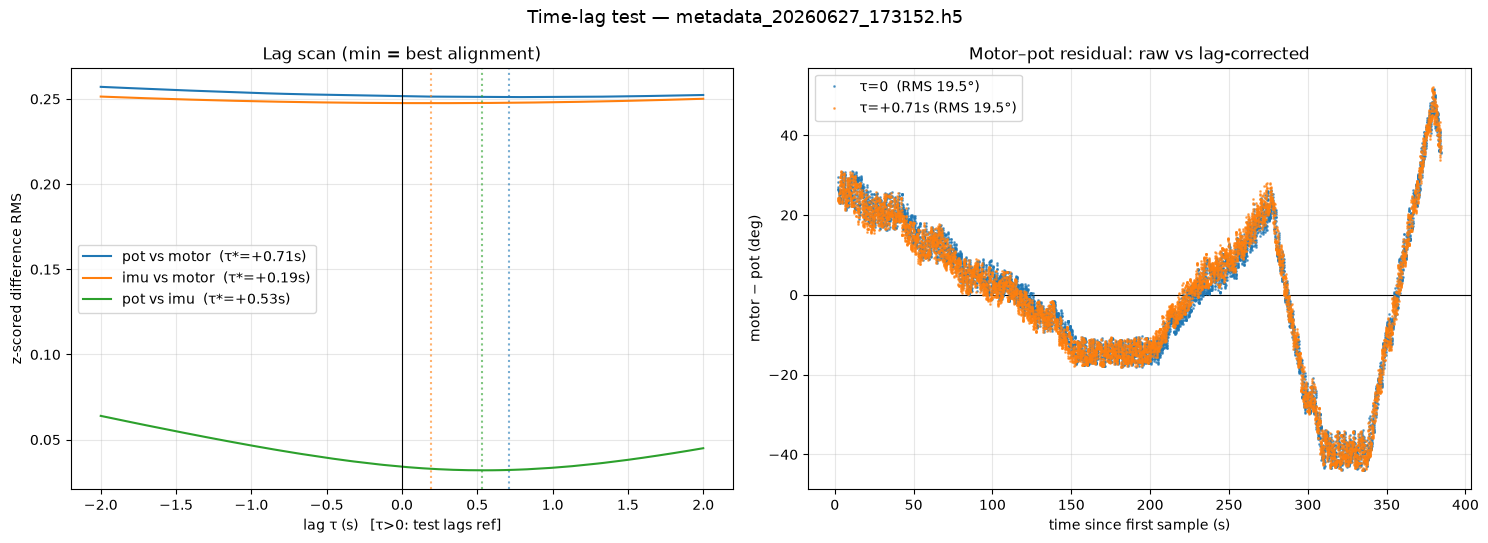

In [4]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(15, 5.5))

# --- lag scan curves ---
for name, (rms_tau, tau_star) in scans.items():
    (line,) = ax0.plot(taus, rms_tau, label=f"{name}  (τ*={tau_star:+.2f}s)")
    ax0.axvline(tau_star, color=line.get_color(), ls=":", alpha=0.6)
ax0.axvline(0, color="k", lw=0.8)
ax0.set_xlabel("lag τ (s)   [τ>0: test lags ref]")
ax0.set_ylabel("z-scored difference RMS")
ax0.set_title("Lag scan (min = best alignment)")
ax0.legend()
ax0.grid(alpha=0.3)

# --- motor-pot residual: before vs after lag correction ---
ax1.axhline(0, color="k", lw=0.8)
ax1.plot(grid, r0, ".", ms=2, alpha=0.6, label=f"τ=0  (RMS {rms(r0):.1f}°)")
ax1.plot(
    grid,
    r1,
    ".",
    ms=2,
    alpha=0.6,
    label=f"τ={tau_pm:+.2f}s (RMS {rms(r1):.1f}°)",
)
ax1.set_xlabel("time since first sample (s)")
ax1.set_ylabel("motor − pot (deg)")
ax1.set_title("Motor–pot residual: raw vs lag-corrected")
ax1.legend()
ax1.grid(alpha=0.3)

fig.suptitle("Time-lag test \u2014 metadata_20260627_173152.h5", fontsize=13)
fig.tight_layout()
out = Path.cwd() / "03_time_lag.png"
fig.savefig(out, dpi=120, bbox_inches="tight")
print("saved", out)